Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import VarianceThreshold
import joblib

Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Big Data & Data Mining/UAS BIG DATA & DATA MINING_23.11.5391_Raditya Julian Primasakti/games.csv.zip")

print("Jumlah data:", df.shape[0])
print("Jumlah fitur:", df.shape[1])
df.head()

Jumlah data: 50872
Jumlah fitur: 13


,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,9.99,0.0,True
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,2.99,0.0,True
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,14.99,0.0,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True


Informasi Struktur Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50872 entries, 0 to 50871
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   app_id          50872 non-null  int64  
 1   title           50872 non-null  object 
 2   date_release    50872 non-null  object 
 3   win             50872 non-null  bool   
 4   mac             50872 non-null  bool   
 5   linux           50872 non-null  bool   
 6   rating          50872 non-null  object 
 7   positive_ratio  50872 non-null  int64  
 8   user_reviews    50872 non-null  int64  
 9   price_final     50872 non-null  float64
 10  price_original  50872 non-null  float64
 11  discount        50872 non-null  float64
 12  steam_deck      50872 non-null  bool   
dtypes: bool(4), float64(3), int64(3), object(3)
memory usage: 3.7+ MB


Statistik Deskriptif Dataset

In [ ]:
df.describe()

,app_id,positive_ratio,user_reviews,price_final,price_original,discount
count,5.087200e+04,50872.000000,5.087200e+04,50872.000000,50872.000000,50872.000000
mean,1.055224e+06,77.052033,1.824425e+03,8.620325,8.726788,5.592212
std,6.103249e+05,18.253592,4.007352e+04,11.514164,11.507021,18.606679
min,1.000000e+01,0.000000,1.000000e+01,0.000000,0.000000,0.000000
25%,5.287375e+05,67.000000,1.900000e+01,0.990000,0.990000,0.000000
50%,9.860850e+05,81.000000,4.900000e+01,4.990000,4.990000,0.000000
75%,1.524895e+06,91.000000,2.060000e+02,10.990000,11.990000,0.000000
max,2.599300e+06,100.000000,7.494460e+06,299.990000,299.990000,90.000000


Seleksi Atribut

In [ ]:
data = df[['title', 'user_reviews', 'positive_ratio', 'price_final']].copy()
data.head()

,title,user_reviews,positive_ratio,price_final
0,Prince of Persia: Warrior Within™,2199,84,9.99
1,BRINK: Agents of Change,21,85,2.99
2,Monaco: What's Yours Is Mine,3722,92,14.99
3,Escape Dead Island,873,61,14.99
4,Dungeon of the ENDLESS™,8784,88,11.99


Data Preprocessing

In [ ]:
data = data.dropna()
data = data[data['user_reviews'] > 0]
data = data[data['positive_ratio'] > 0]

Transformasi Data (Memakai Skewness)

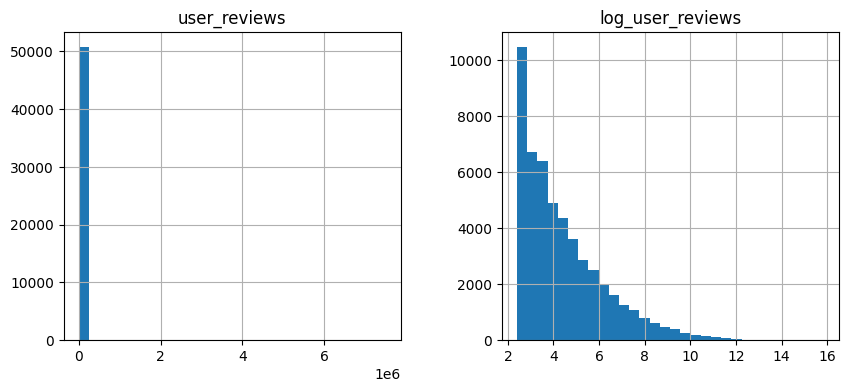

In [ ]:
data['log_user_reviews'] = np.log1p(data['user_reviews'])

data[['user_reviews', 'log_user_reviews']].hist(bins=30, figsize=(10,4))
plt.show()

EXPLORATORY DATA ANALYSIS (EDA)

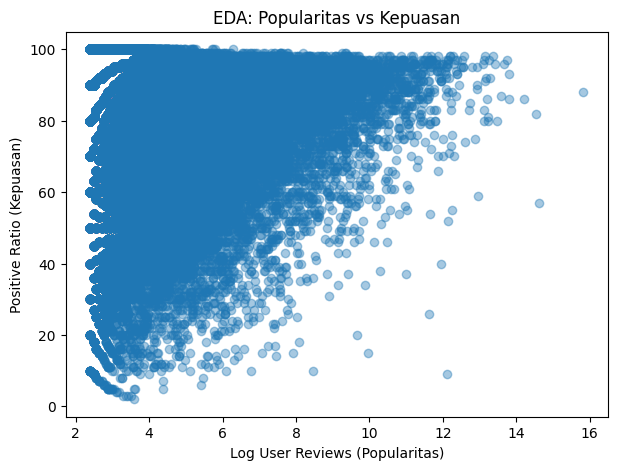

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(data['log_user_reviews'], data['positive_ratio'], alpha=0.4)
plt.xlabel("Log User Reviews (Popularitas)")
plt.ylabel("Positive Ratio (Kepuasan)")
plt.title("EDA: Popularitas vs Kepuasan")
plt.show()

FEATURE SELECTION

In [ ]:
X_fs = data[['log_user_reviews', 'positive_ratio', 'price_final']]

selector = VarianceThreshold(threshold=0.01)
X_selected = selector.fit_transform(X_fs)

selected_features = X_fs.columns[selector.get_support()]
selected_features

Index(['log_user_reviews', 'positive_ratio', 'price_final'], dtype='object')

Modeling

In [ ]:
X = data[selected_features]

Normalisasi Data

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Penentuan Jumlah Cluster

In [ ]:
silhouette_scores = []

for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}, Silhouette Score={score:.3f}")

k=2, Silhouette Score=0.355
k=3, Silhouette Score=0.318
k=4, Silhouette Score=0.360
k=5, Silhouette Score=0.290
k=6, Silhouette Score=0.296


Visualisasi

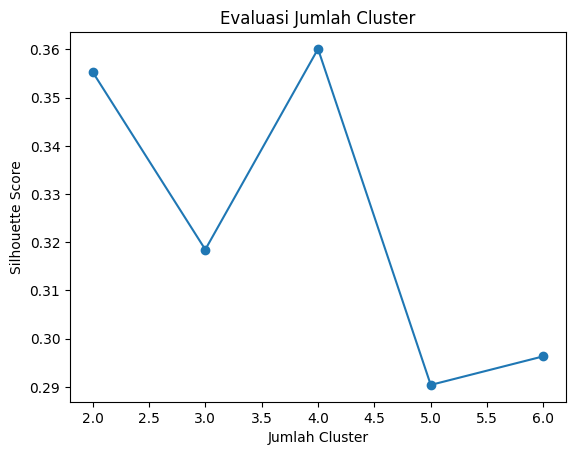

In [ ]:
plt.plot(range(2,7), silhouette_scores, marker='o')
plt.xlabel("Jumlah Cluster")
plt.ylabel("Silhouette Score")
plt.title("Evaluasi Jumlah Cluster")
plt.show()

Modeling (K-Means)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
data['cluster'] = kmeans.fit_predict(X_scaled)

Visualisasi Hasil Clustering

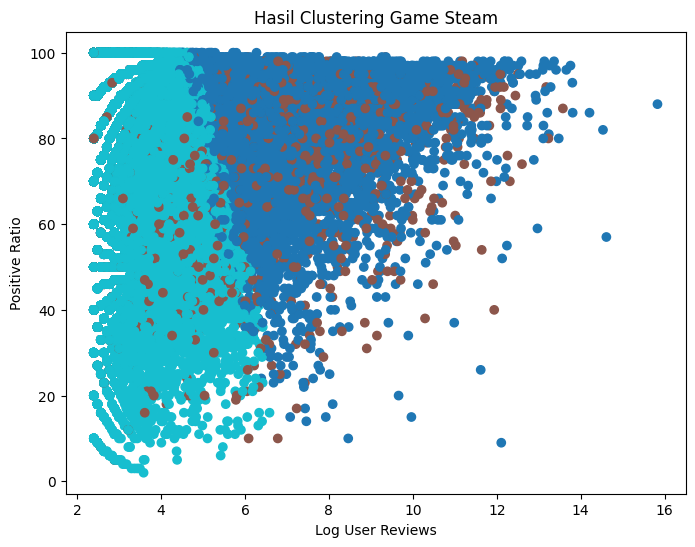

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(data['log_user_reviews'], data['positive_ratio'],
            c=data['cluster'], cmap='tab10')
plt.xlabel("Log User Reviews")
plt.ylabel("Positive Ratio")
plt.title("Hasil Clustering Game Steam")
plt.show()

ANALISA CLUSTER

In [ ]:
cluster_summary = data.groupby('cluster')[['user_reviews','positive_ratio','price_final']].mean()
cluster_summary

,user_reviews,positive_ratio,price_final
cluster,,,
0,6122.733176,83.638588,9.502809
1,4709.357630,73.435548,42.127009
2,46.200413,75.013621,5.654937


Identifikasi Game Anomali

In [ ]:
anomali_cluster = 2 # Assuming cluster 2 represents an anomaly based on very low user reviews
anomali_games = data[data['cluster'] == anomali_cluster]

anomali_games[['title', 'user_reviews', 'positive_ratio', 'price_final']] \
    .sort_values('user_reviews', ascending=False) \
    .head(10)

,title,user_reviews,positive_ratio,price_final
28517,Malice,723,16,7.99
34127,Hide vs. Seek,615,36,0.00
25502,Resident Evil Village - Trauma Pack,614,23,12.99
34364,TEKKEN 7 - DLC13: Frame Data Display,605,14,1.49
34875,Better Late Than DEAD,604,29,4.99
37432,Ampersand,568,32,1.99
37648,Tom Clancy's Ghost Recon® Wildlands - Narco Road,564,16,14.99
10236,DK Online,562,41,0.00
41550,CrazyFlasher7 Mercenary Empire,553,30,0.00
29247,Airport Simulator 2014,553,13,4.99


SIMPAN MODEL

In [ ]:
save_path = r"/content/drive/MyDrive/Big Data & Data Mining/UAS BIG DATA & DATA MINING_23.11.5391_Raditya Julian Primasakti"

import os
os.makedirs(save_path, exist_ok=True)

import joblib

joblib.dump(kmeans, f"{save_path}/kmeans_game_anomaly_model.pkl")
joblib.dump(scaler, f"{save_path}/scaler.pkl")

print("Model dan scaler berhasil disimpan ke Google Drive.")


Model dan scaler berhasil disimpan ke Google Drive.


In [55]:
os.listdir(save_path)

['23.11.5391_Raditya Julian Primasakti_UAS Big Data & Data Mining.ipynb',
 'games.csv.zip',
 'kmeans_game_anomaly_model.pkl',
 'scaler.pkl']